In [10]:
import json
import pathlib
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

warnings.filterwarnings('ignore')
sys.path.insert(0, str(pathlib.Path('..') / 'src'))

from metrics.self_reinforcement import extract_runs, summarise_runs
from metrics.dominance import score_dominance_all, summarise_dominance
from metrics.bistability import analyse_bistability
from metrics.limit_cycles import detect_agent_limit_cycles

ROOT = pathlib.Path('..')
MAS_DIR = ROOT / 'results' / 'mas' / 'final_dataset'
LING_DIR = ROOT / 'results' / 'linguistic_mistral' / 'message'
DIMS = ['conviction', 'anchoring', 'dialogic']
MAX_REP = 9  # linguistic scores only available for reps 0-9; align MAS to same window

CAT = ['#2a78d6', '#008300', '#e87ba4', '#eda100', '#1baf7a']
SURFACE = '#fcfcfb'
TEXT_PRI = '#0b0b0b'
TEXT_SEC = '#52514e'
GRID = '#e1e0d9'

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'axes.edgecolor': '#c3c2b7', 'axes.labelcolor': TEXT_SEC,
    'xtick.color': TEXT_SEC, 'ytick.color': TEXT_SEC,
    'text.color': TEXT_PRI, 'axes.grid': True,
    'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.axisbelow': True, 'font.size': 10,
})

## Load linguistic scores (reps 0–4, cell-level means)

In [11]:
ling_rows = []
for f in LING_DIR.glob('**/*.json'):
    ling_rows.extend(json.loads(f.read_text()))

ling_df = pd.DataFrame(ling_rows)
ling_df = ling_df[ling_df['rep_idx'] <= MAX_REP]

# Aggregate to cell level: mean score per (dataset, topology, W, qid)
ling_cell = (
    ling_df.groupby(['dataset', 'topology', 'W', 'qid'])[DIMS]
    .mean()
    .reset_index()
)
print(f'Linguistic cells: {len(ling_cell)}')
ling_cell.head()

Linguistic cells: 420


,dataset,topology,W,qid,conviction,anchoring,dialogic
0,gpqa,fc,1,109,3.656977,2.290698,2.168605
1,gpqa,fc,1,111,3.583333,2.791667,2.972222
2,gpqa,fc,1,117,3.267857,2.250000,2.250000
3,gpqa,fc,1,12,3.500000,3.166667,3.645833
4,gpqa,fc,1,125,3.548611,3.381944,3.694444


## Compute MAS metrics per cell

This iterates all 420 cells. Takes ~5–10 min (dominance + bistability are the heavy ones). Results are cached in `metrics_df`.

In [12]:
import time

mas_files = list(MAS_DIR.glob('**/*.json'))
records = []

for i, fp in enumerate(mas_files):
    d = json.loads(fp.read_text())
    all_reps = d['repetitions']
    reps = [r for r in all_reps if r.get('repetition', r.get('rep_idx', 0)) <= MAX_REP]
    options = tuple(d['options'])
    key = {
        'dataset': d['dataset'],
        'topology': d.get('topology_name', 'fc'),
        'W': d['W'],
        'qid': str(d['question_id']),
    }

    accuracy = np.mean([r['correct'] for r in reps]) if reps else np.nan
    mean_rounds = np.mean([len(r['trajectory']) for r in reps]) if reps else np.nan

    runs = extract_runs(reps)
    sr = summarise_runs(runs)

    dom_reps = score_dominance_all(reps)
    dom = summarise_dominance(dom_reps)

    bis = analyse_bistability(reps, options=options, B=200, B_boot=200, seed=0)

    lc_rows = detect_agent_limit_cycles(reps, B=200, seed=0)
    lc_frac = np.mean([r['lc'] for r in lc_rows]) if lc_rows else np.nan

    records.append({**key,
        'accuracy': accuracy, 'mean_rounds': mean_rounds,
        'p_sr': sr['p_sr'], 'mean_slope': sr['mean_slope'],
        'D_mean': dom['D_mean'], 'flagged_frac': dom['flagged_fraction'],
        'n_eff': bis['n_eff'], 'bis_label': bis['label'],
        'lc_frac': lc_frac,
    })

    if (i + 1) % 50 == 0:
        print(f'  {i+1}/{len(mas_files)}')

metrics_df = pd.DataFrame(records)
print(f'Done. {len(metrics_df)} cells')
metrics_df.head()

  50/420
  100/420
  150/420
  200/420
  250/420
  300/420
  350/420
  400/420
Done. 420 cells


,dataset,topology,W,qid,accuracy,mean_rounds,p_sr,mean_slope,D_mean,flagged_frac,n_eff,bis_label,lc_frac
0,gpqa,star,1,84,0.3,7.0,0.820000,0.460558,0.518338,0.0,3.571429,stochastic,0.0
1,gpqa,star,1,24,0.5,5.1,0.777778,0.461164,0.761867,0.0,2.380952,stochastic,0.0
2,hiddenbench,star,1,34,0.1,9.0,0.882353,0.271699,0.730993,NaN,2.314286,stochastic,0.0
3,hiddenbench,star,1,22,0.7,7.0,0.854167,0.445563,0.550147,0.0,1.851852,stochastic,0.0
4,hiddenbench,star,1,18,0.3,7.1,0.886364,0.380159,0.640147,0.0,1.800000,multistable,0.0


## Join linguistic and MAS metrics

In [13]:
merged = ling_cell.merge(metrics_df, on=['dataset', 'topology', 'W', 'qid'], how='inner')
print(f'Merged cells: {len(merged)}')

MAS_METRICS = [
    ('accuracy',    'Accuracy'),
    ('mean_rounds', 'Rounds (efficiency)'),
    ('p_sr',        'Self-reinforcement (p_sr)'),
    ('mean_slope',  'SR slope'),
    ('D_mean',      'Dominance (D)'),
    ('flagged_frac','Dominance flagged frac'),
    ('n_eff',       'Bistability (n_eff)'),
    ('lc_frac',     'Limit-cycle frac'),
]
merged.head()

Merged cells: 420


,dataset,topology,W,qid,conviction,anchoring,dialogic,accuracy,mean_rounds,p_sr,mean_slope,D_mean,flagged_frac,n_eff,bis_label,lc_frac
0,gpqa,fc,1,109,3.656977,2.290698,2.168605,0.1,7.3,0.727273,0.342916,0.121568,0.111111,2.380952,stochastic,0.0
1,gpqa,fc,1,111,3.583333,2.791667,2.972222,0.7,4.8,0.904762,0.634070,0.164184,0.000000,1.724138,stochastic,0.0
2,gpqa,fc,1,117,3.267857,2.250000,2.250000,0.2,4.4,0.875000,0.603571,0.186007,0.000000,1.851852,multistable,0.0
3,gpqa,fc,1,12,3.500000,3.166667,3.645833,0.4,5.0,0.809524,0.492517,0.130394,0.000000,1.923077,stochastic,0.0
4,gpqa,fc,1,125,3.548611,3.381944,3.694444,0.4,6.6,0.851064,0.479643,0.103139,0.125000,1.923077,stochastic,0.0


## Spearman correlation heatmap: dimensions × MAS metrics

            Accuracy  Rounds (efficiency)  Self-reinforcement (p_sr)  \
conviction     0.112               -0.300                     -0.189   
anchoring      0.099               -0.258                     -0.292   
dialogic       0.112               -0.194                     -0.279   

            SR slope  Dominance (D)  Dominance flagged frac  \
conviction     0.154          0.067                  -0.057   
anchoring      0.134         -0.086                   0.097   
dialogic       0.086          0.179                  -0.037   

            Bistability (n_eff)  Limit-cycle frac  
conviction               -0.085            -0.012  
anchoring                 0.024             0.005  
dialogic                  0.036            -0.043  

p-values:
            Accuracy  Rounds (efficiency)  Self-reinforcement (p_sr)  \
conviction     0.022                  0.0                        0.0   
anchoring      0.042                  0.0                        0.0   
dialogic       0.022   

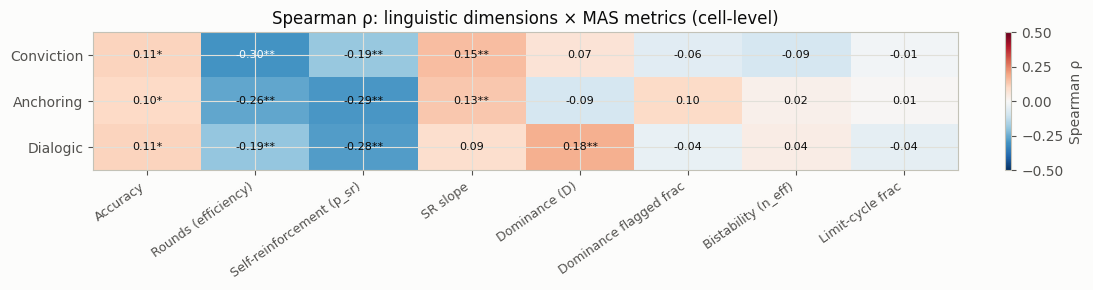

In [14]:
metric_cols  = [m for m, _ in MAS_METRICS]
metric_labels = [l for _, l in MAS_METRICS]

corr = np.zeros((len(DIMS), len(metric_cols)))
pval = np.zeros_like(corr)

for i, dim in enumerate(DIMS):
    for j, col in enumerate(metric_cols):
        sub = merged[[dim, col]].dropna()
        if len(sub) < 5:
            corr[i, j] = np.nan
            pval[i, j] = np.nan
        else:
            r, p = stats.spearmanr(sub[dim], sub[col])
            corr[i, j] = r
            pval[i, j] = p

corr_df = pd.DataFrame(corr, index=DIMS, columns=metric_labels)
pval_df = pd.DataFrame(pval, index=DIMS, columns=metric_labels)
print(corr_df.round(3))
print('\np-values:')
print(pval_df.round(3))

fig, ax = plt.subplots(figsize=(11, 3))
vmax = 0.5
im = ax.imshow(corr, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
ax.set_xticks(range(len(metric_labels)))
ax.set_xticklabels(metric_labels, rotation=35, ha='right', fontsize=9)
ax.set_yticks(range(len(DIMS)))
ax.set_yticklabels([d.capitalize() for d in DIMS])
ax.set_title('Spearman ρ: linguistic dimensions × MAS metrics (cell-level)', color=TEXT_PRI)

for i in range(len(DIMS)):
    for j in range(len(metric_cols)):
        r, p = corr[i, j], pval[i, j]
        if np.isnan(r):
            continue
        sig = '**' if p < 0.01 else ('*' if p < 0.05 else '')
        ax.text(j, i, f'{r:.2f}{sig}', ha='center', va='center',
                fontsize=8, color='white' if abs(r) > 0.3 else TEXT_PRI)

plt.colorbar(im, ax=ax, label='Spearman ρ', fraction=0.015)
plt.tight_layout()
plt.show()

## Scatter plots for strongest correlations

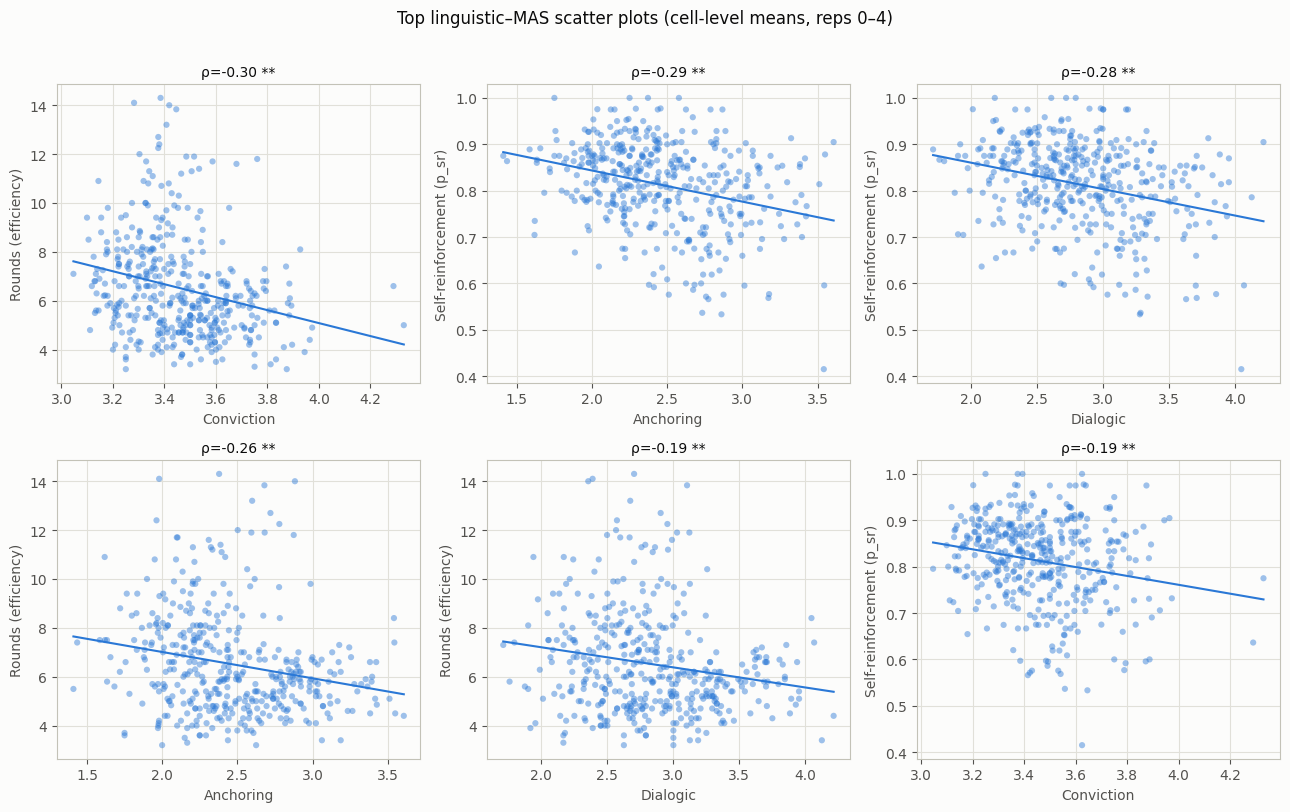

In [15]:
# Pick up to 3 strongest pairs by |rho| and plot them
pairs = []
for i, dim in enumerate(DIMS):
    for j, (col, label) in enumerate(MAS_METRICS):
        pairs.append((abs(corr[i, j]), dim, col, label, corr[i, j], pval[i, j]))
pairs.sort(reverse=True)
top = [(d, c, l, r, p) for _, d, c, l, r, p in pairs[:6]]

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
fig.suptitle('Top linguistic–MAS scatter plots (cell-level means, reps 0–4)', fontsize=12, y=1.01, color=TEXT_PRI)

for ax, (dim, col, label, rho, p) in zip(axes.flat, top):
    sub = merged[[dim, col]].dropna()
    ax.scatter(sub[dim], sub[col], alpha=0.45, s=20, color=CAT[0], edgecolors='none')
    m, b = np.polyfit(sub[dim], sub[col], 1)
    xs = np.linspace(sub[dim].min(), sub[dim].max(), 100)
    ax.plot(xs, m * xs + b, color=CAT[0], linewidth=1.5)
    sig = '**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.')
    ax.set_xlabel(dim.capitalize(), color=TEXT_SEC)
    ax.set_ylabel(label, color=TEXT_SEC)
    ax.set_title(f'ρ={rho:.2f} {sig}', fontsize=10, color=TEXT_PRI)

plt.tight_layout()
plt.show()

## Distributions by bistability label

Do monostable vs multistable tasks produce systematically different language?

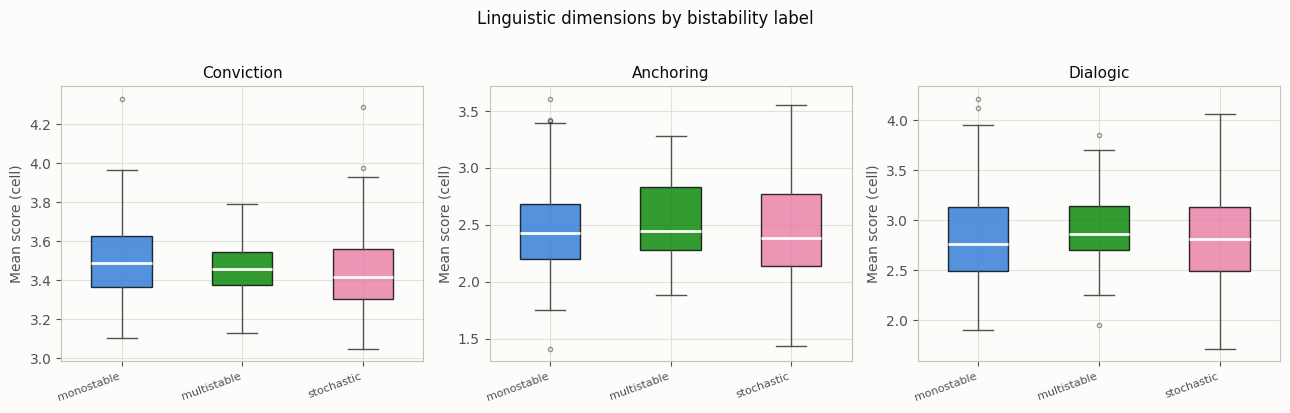

Kruskal-Wallis (bistability label):
  conviction: H=8.31, p=0.0157
  anchoring: H=2.25, p=0.3243
  dialogic: H=0.60, p=0.7405


In [16]:
labels_order = ['monostable', 'multistable', 'stochastic', 'insufficient']
colors_bis = {l: c for l, c in zip(labels_order, CAT)}

present = [l for l in labels_order if l in merged['bis_label'].values]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Linguistic dimensions by bistability label', fontsize=12, y=1.02, color=TEXT_PRI)

for ax, dim in zip(axes, DIMS):
    data = [merged.loc[merged['bis_label'] == l, dim].dropna().values for l in present]
    bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                    medianprops={'color': SURFACE, 'linewidth': 2},
                    whiskerprops={'color': TEXT_SEC},
                    capprops={'color': TEXT_SEC},
                    flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.4, 'color': TEXT_SEC})
    for patch, l in zip(bp['boxes'], present):
        patch.set_facecolor(colors_bis[l])
        patch.set_alpha(0.8)
    ax.set_xticklabels(present, rotation=20, ha='right', fontsize=8)
    ax.set_title(dim.capitalize(), fontsize=11, color=TEXT_PRI)
    ax.set_ylabel('Mean score (cell)', color=TEXT_SEC)

plt.tight_layout()
plt.show()

# Kruskal-Wallis test
print('Kruskal-Wallis (bistability label):')
for dim in DIMS:
    groups = [merged.loc[merged['bis_label'] == l, dim].dropna().values for l in present]
    groups = [g for g in groups if len(g) > 1]
    if len(groups) >= 2:
        H, p = stats.kruskal(*groups)
        print(f'  {dim}: H={H:.2f}, p={p:.4f}')

## Topology & window: do linguistic differences track structural differences?

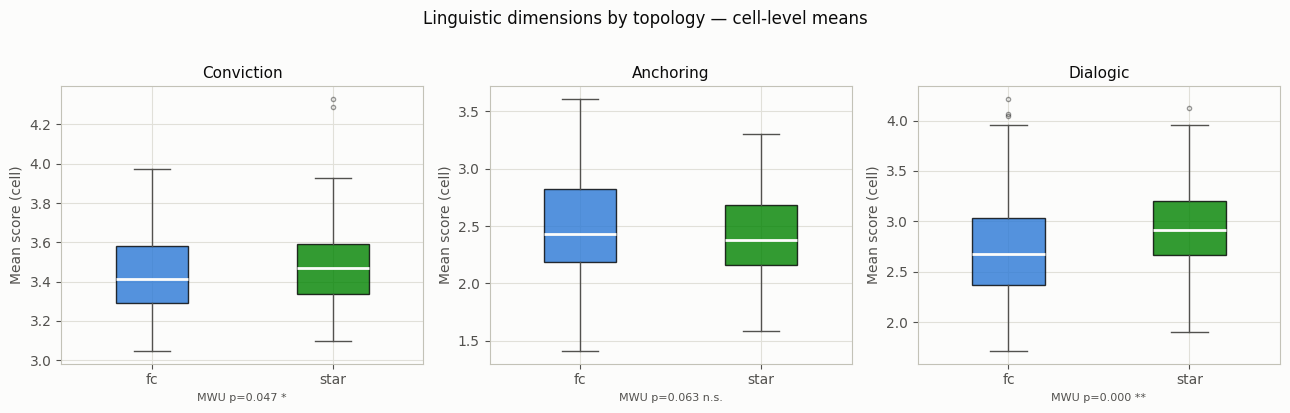

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Linguistic dimensions by topology — cell-level means', fontsize=12, y=1.02, color=TEXT_PRI)

topos = sorted(merged['topology'].unique())
colors_t = {t: c for t, c in zip(topos, CAT)}

for ax, dim in zip(axes, DIMS):
    data = [merged.loc[merged['topology'] == t, dim].dropna().values for t in topos]
    bp = ax.boxplot(data, patch_artist=True, widths=0.4,
                    medianprops={'color': SURFACE, 'linewidth': 2},
                    whiskerprops={'color': TEXT_SEC}, capprops={'color': TEXT_SEC},
                    flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.4, 'color': TEXT_SEC})
    for patch, t in zip(bp['boxes'], topos):
        patch.set_facecolor(colors_t[t])
        patch.set_alpha(0.8)
    ax.set_xticklabels(topos)
    ax.set_title(dim.capitalize(), fontsize=11, color=TEXT_PRI)
    ax.set_ylabel('Mean score (cell)', color=TEXT_SEC)
    u, p = stats.mannwhitneyu(*data, alternative='two-sided') if len(data) == 2 else (np.nan, np.nan)
    sig = '**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.')
    ax.set_xlabel(f'MWU p={p:.3f} {sig}', color=TEXT_SEC, fontsize=8)

plt.tight_layout()
plt.show()

## Summary table: Spearman ρ with significance

In [18]:
rows_out = []
for i, dim in enumerate(DIMS):
    for j, (col, label) in enumerate(MAS_METRICS):
        r, p = corr[i, j], pval[i, j]
        sig = '**' if p < 0.01 else ('*' if p < 0.05 else '')
        rows_out.append({'dimension': dim, 'metric': label,
                         'rho': round(r, 3), 'p': round(p, 4), 'sig': sig})

summary_tbl = pd.DataFrame(rows_out).sort_values('rho', key=abs, ascending=False)
summary_tbl.head(15)

,dimension,metric,rho,p,sig
1,conviction,Rounds (efficiency),-0.300,0.0000,**
10,anchoring,Self-reinforcement (p_sr),-0.292,0.0000,**
18,dialogic,Self-reinforcement (p_sr),-0.279,0.0000,**
9,anchoring,Rounds (efficiency),-0.258,0.0000,**
17,dialogic,Rounds (efficiency),-0.194,0.0001,**
2,conviction,Self-reinforcement (p_sr),-0.189,0.0001,**
20,dialogic,Dominance (D),0.179,0.0002,**
3,conviction,SR slope,0.154,0.0016,**
11,anchoring,SR slope,0.134,0.0058,**
0,conviction,Accuracy,0.112,0.0215,*


## Hub vs leaf nodes (star topology)

In the star topology agent 0 is the hub (connected to all others); agents 1–3 are leaves.
Do hub and leaves produce systematically different language?

=== Mean scores by role ===
      conviction  anchoring  dialogic
role                                 
hub        3.443      2.364     2.892
leaf       3.443      2.332     2.843

=== n messages ===
role
leaf    25578
hub      8526
Name: count, dtype: int64


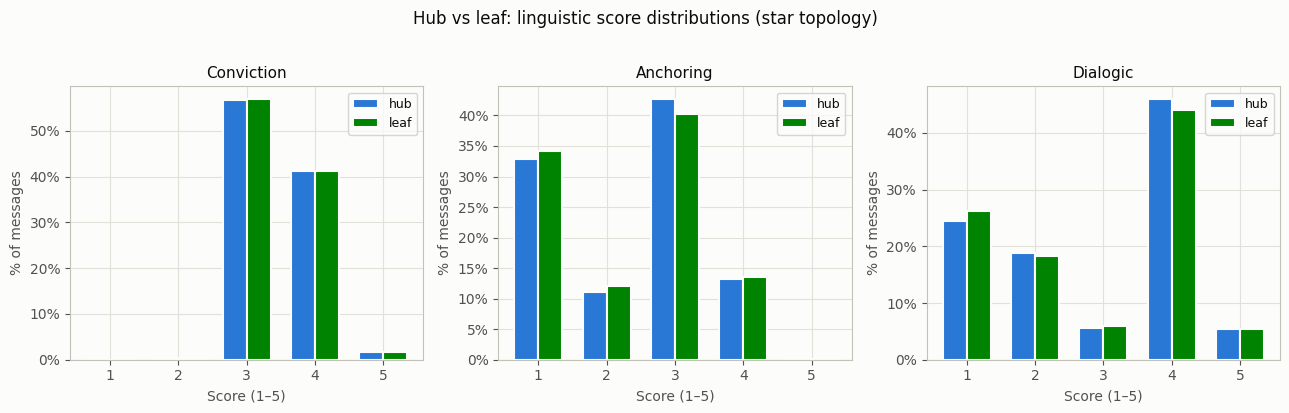


=== Mann-Whitney U: hub vs leaf ===
  conviction    hub_mean=3.443  leaf_mean=3.443  p=0.9861  n.s.
  anchoring     hub_mean=2.364  leaf_mean=2.332  p=0.0224  *
  dialogic      hub_mean=2.892  leaf_mean=2.843  p=0.0034  **


In [19]:
star_ling = ling_df[ling_df['topology'] == 'star'].copy()
star_ling['role'] = star_ling['agent_idx'].apply(lambda x: 'hub' if x == 0 else 'leaf')

print("=== Mean scores by role ===")
print(star_ling.groupby('role')[DIMS].mean().round(3))
print()
print("=== n messages ===")
print(star_ling['role'].value_counts())

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Hub vs leaf: linguistic score distributions (star topology)', fontsize=12, y=1.02, color=TEXT_PRI)

roles = ['hub', 'leaf']
colors_r = {'hub': CAT[0], 'leaf': CAT[1]}
width = 0.35

for ax, dim in zip(axes, DIMS):
    for i, role in enumerate(roles):
        sub = star_ling[star_ling['role'] == role]
        counts = sub[dim].value_counts().reindex([1, 2, 3, 4, 5], fill_value=0)
        pct = counts / counts.sum() * 100
        offset = (i - 0.5) * width
        ax.bar([x + offset for x in pct.index], pct.values,
               width=width, label=role, color=colors_r[role], edgecolor=SURFACE, linewidth=1.5)
    ax.set_title(dim.capitalize(), fontsize=11, color=TEXT_PRI)
    ax.set_xlabel('Score (1–5)', color=TEXT_SEC)
    ax.set_ylabel('% of messages', color=TEXT_SEC)
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print("\n=== Mann-Whitney U: hub vs leaf ===")
for dim in DIMS:
    hub_vals = star_ling.loc[star_ling['role'] == 'hub', dim].dropna()
    leaf_vals = star_ling.loc[star_ling['role'] == 'leaf', dim].dropna()
    u, p = stats.mannwhitneyu(hub_vals, leaf_vals, alternative='two-sided')
    sig = '**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.')
    print(f"  {dim:12s}  hub_mean={hub_vals.mean():.3f}  leaf_mean={leaf_vals.mean():.3f}  p={p:.4f}  {sig}")

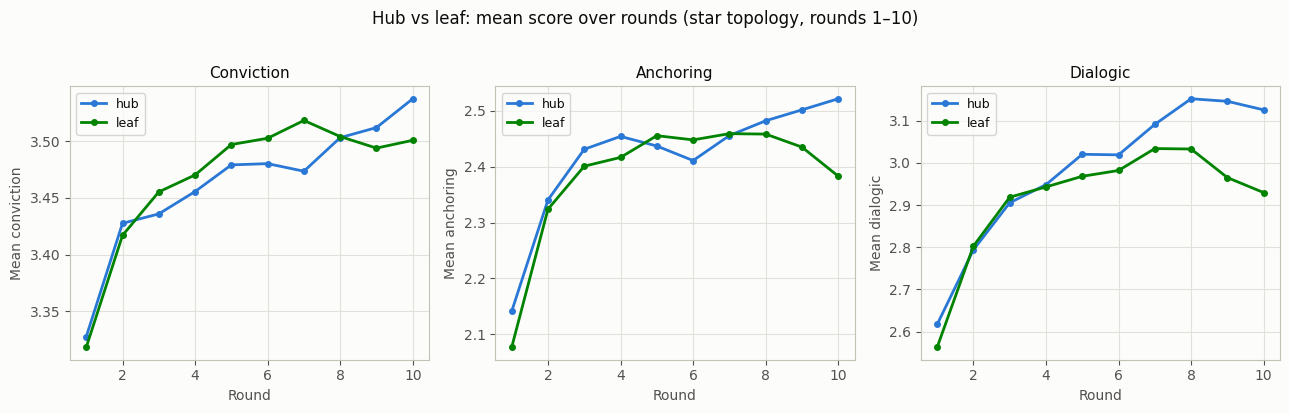

In [20]:
round_means = (
    star_ling.groupby(['round', 'role'])[DIMS]
    .mean()
    .reset_index()
)
max_round = 10
round_means = round_means[round_means['round'] <= max_round]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Hub vs leaf: mean score over rounds (star topology, rounds 1–10)', fontsize=12, y=1.02, color=TEXT_PRI)

for ax, dim in zip(axes, DIMS):
    for role, color in colors_r.items():
        sub = round_means[round_means['role'] == role]
        ax.plot(sub['round'], sub[dim], label=role, color=color, linewidth=2, marker='o', markersize=4)
    ax.set_xlabel('Round', color=TEXT_SEC)
    ax.set_ylabel(f'Mean {dim}', color=TEXT_SEC)
    ax.set_title(dim.capitalize(), fontsize=11, color=TEXT_PRI)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## Agent-level profiles: spider plots

Each agent's mean score per dimension, aggregated over all rounds they participated in (within reps 0–9). This shows whether agents within the same run differentiate by style.

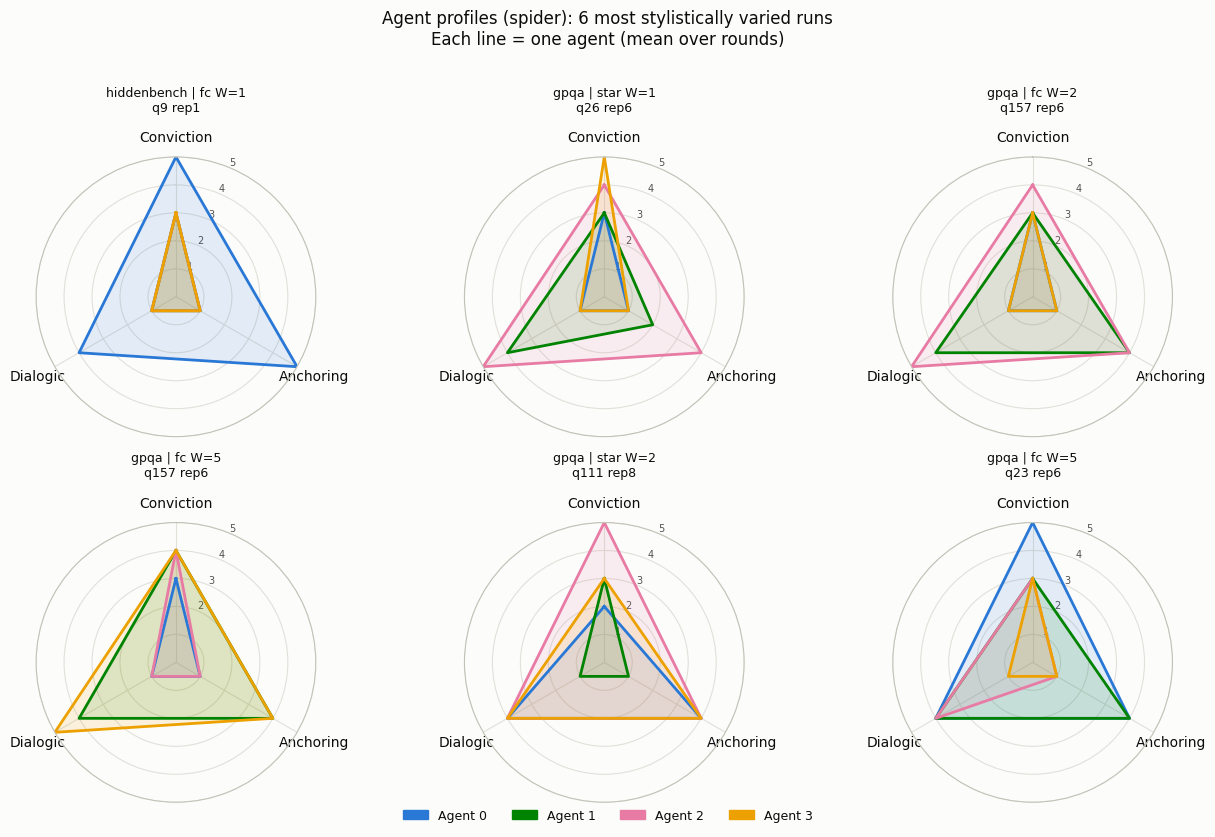

In [26]:
import matplotlib.patches as mpatches

# agent-level: mean across all rounds each agent participated in
agent_df = (
    ling_df.groupby(['dataset', 'topology', 'W', 'qid', 'rep_idx', 'agent_idx'])[DIMS]
    .mean()
    .reset_index()
)

def spider_plot(ax, values_list, colors, dim_labels, title, ylim=(0, 5)):
    N = len(dim_labels)
    angles = [n / N * 2 * np.pi for n in range(N)]
    angles += angles[:1]

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([d.capitalize() for d in dim_labels], size=10, color=TEXT_PRI)
    ax.set_ylim(*ylim)
    ax.set_yticks([0, 1, 2, 3, 4, 5])
    ax.set_yticklabels(['', '1', '2', '3', '4', '5'], size=7, color=TEXT_SEC)
    ax.yaxis.grid(True, color=GRID, linewidth=0.8)
    ax.xaxis.grid(True, color=GRID, linewidth=0.8)
    ax.spines['polar'].set_color('#c3c2b7')
    ax.set_facecolor(SURFACE)

    for vals, color in zip(values_list, colors):
        v = list(vals) + [vals[0]]
        ax.plot(angles, v, color=color, linewidth=2)
        ax.fill(angles, v, color=color, alpha=0.12)

    ax.set_title(title, size=9, color=TEXT_PRI, pad=14)

# Pick 6 runs with high within-run variance
within_std = agent_df.groupby(['dataset', 'topology', 'W', 'qid', 'rep_idx'])[DIMS].std().mean(axis=1)
top_runs = within_std.nlargest(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(13, 8), subplot_kw={'projection': 'polar'})
fig.suptitle('Agent profiles (spider): 6 most stylistically varied runs\nEach line = one agent (mean over rounds)', fontsize=12, y=1.01, color=TEXT_PRI)

for ax, run_key in zip(axes.flat, top_runs):
    ds, topo, W, qid, rep = run_key
    sub = agent_df[
        (agent_df['dataset'] == ds) & (agent_df['topology'] == topo) &
        (agent_df['W'] == W) & (agent_df['qid'] == qid) & (agent_df['rep_idx'] == rep)
    ].sort_values('agent_idx')

    vals_list = [row[DIMS].values for _, row in sub.iterrows()]
    colors = CAT[:len(vals_list)]
    title = f"{ds} | {topo} W={W}\nq{qid} rep{rep}"
    spider_plot(ax, vals_list, colors, DIMS, title)

legend_handles = [mpatches.Patch(color=CAT[i], label=f'Agent {i}') for i in range(4)]
fig.legend(handles=legend_handles, loc='lower center', ncol=4, fontsize=9,
           frameon=False, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()

## Round-level trajectories for the same example runs

Shows how each agent's scores evolve round by round — not just their average.

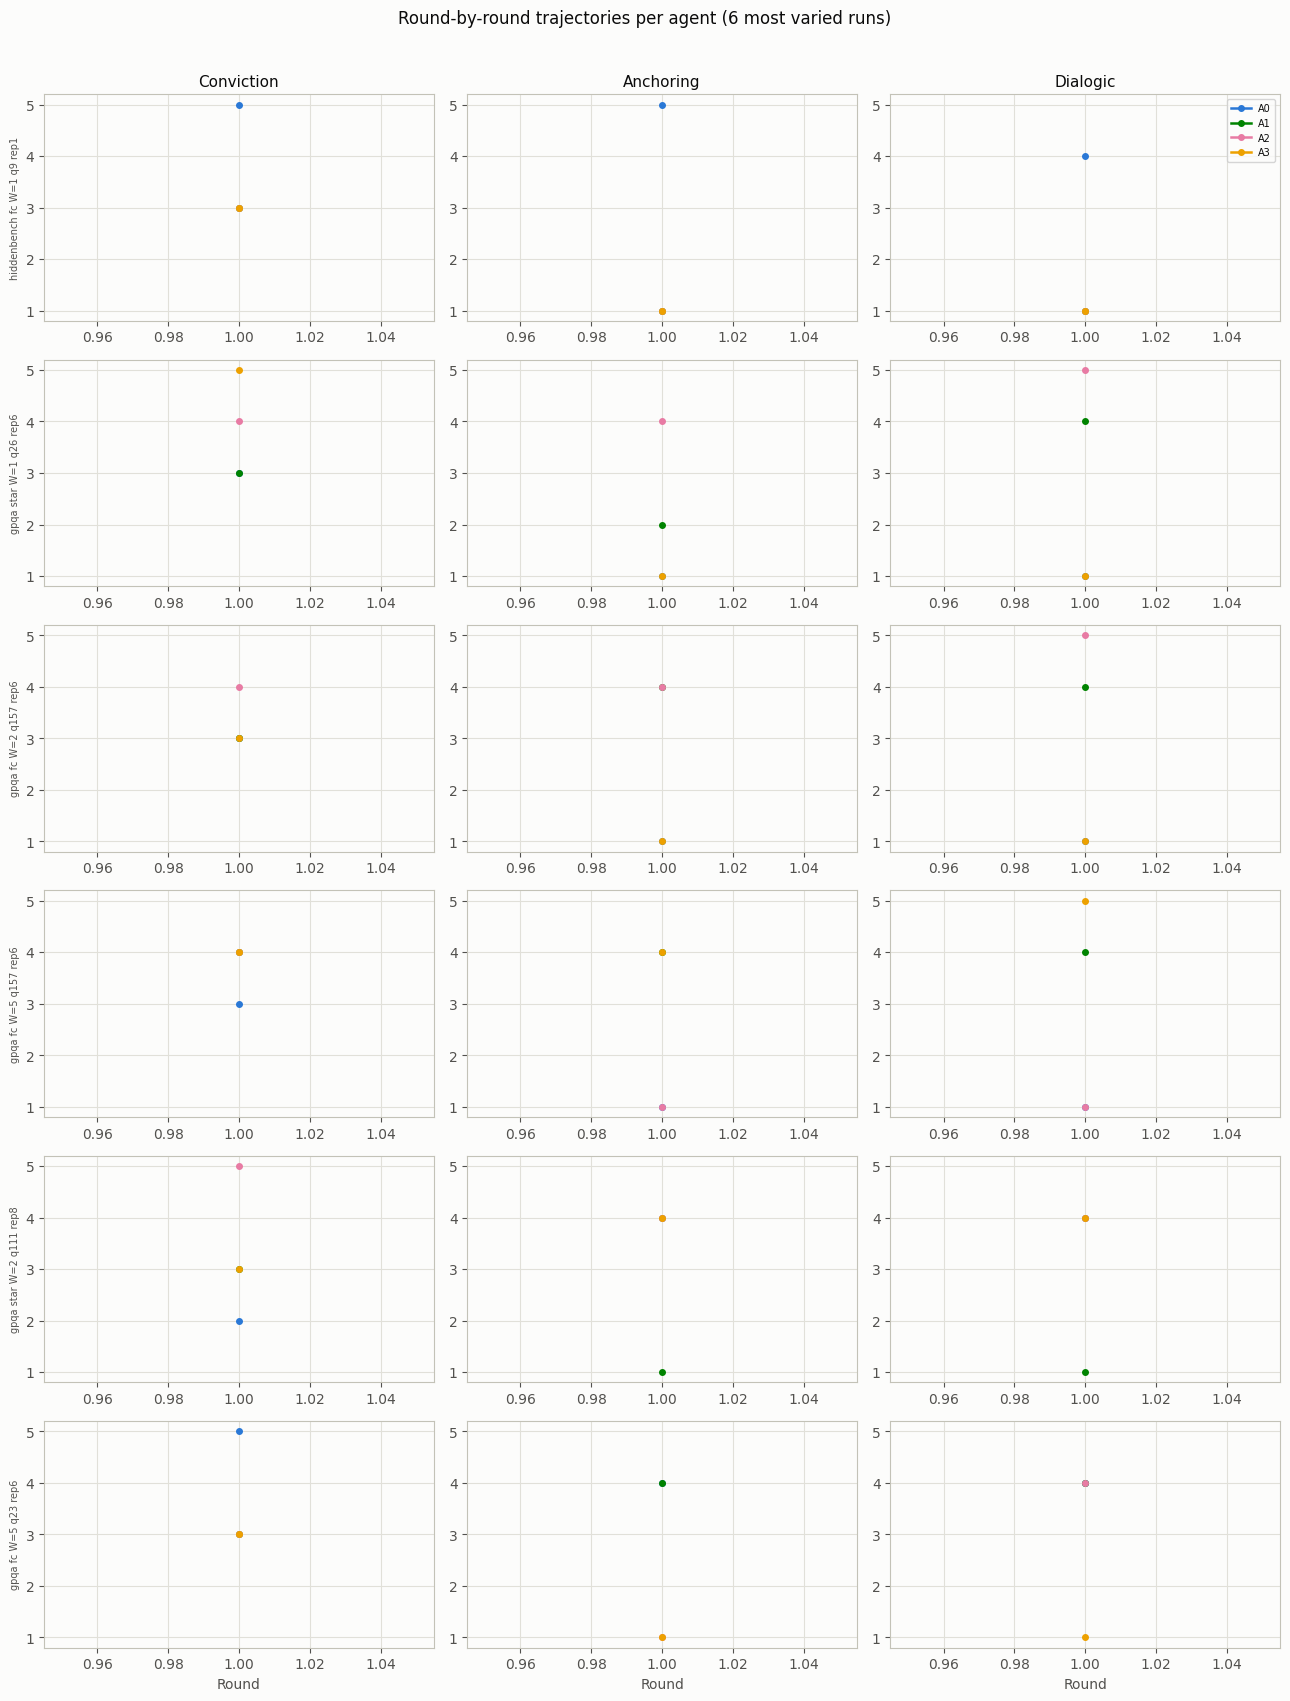

In [22]:
agent_round_df = (
    ling_df.groupby(['dataset', 'topology', 'W', 'qid', 'rep_idx', 'agent_idx', 'round'])[DIMS]
    .mean()
    .reset_index()
)

# Use the same 6 top-varied runs
n_runs = len(top_runs)
fig, axes = plt.subplots(n_runs, 3, figsize=(13, n_runs * 2.8))
fig.suptitle('Round-by-round trajectories per agent (6 most varied runs)', fontsize=12, y=1.01, color=TEXT_PRI)

for row_i, run_key in enumerate(top_runs):
    ds, topo, W, qid, rep = run_key
    sub = agent_round_df[
        (agent_round_df['dataset'] == ds) & (agent_round_df['topology'] == topo) &
        (agent_round_df['W'] == W) & (agent_round_df['qid'] == qid) &
        (agent_round_df['rep_idx'] == rep)
    ]
    agents = sorted(sub['agent_idx'].unique())
    run_label = f"{ds} {topo} W={W} q{qid} rep{rep}"

    for col_i, dim in enumerate(DIMS):
        ax = axes[row_i, col_i]
        for a_idx, agent in enumerate(agents):
            ag = sub[sub['agent_idx'] == agent].sort_values('round')
            ax.plot(ag['round'], ag[dim], color=CAT[a_idx], linewidth=1.8,
                    marker='o', markersize=4, label=f'A{int(agent)}')
        ax.set_ylim(0.8, 5.2)
        ax.set_yticks([1, 2, 3, 4, 5])
        if col_i == 0:
            ax.set_ylabel(run_label, fontsize=7, color=TEXT_SEC)
        if row_i == 0:
            ax.set_title(dim.capitalize(), fontsize=11, color=TEXT_PRI)
        if row_i == n_runs - 1:
            ax.set_xlabel('Round', color=TEXT_SEC)
        if col_i == 2 and row_i == 0:
            ax.legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.show()

## Between-agent variance: does stylistic diversity within a run predict outcomes?

=== Overall within-run between-agent std ===
  conviction: mean=0.321  median=0.300  >0.5: 11.2%
  anchoring: mean=0.750  median=0.720  >0.5: 68.8%
  dialogic: mean=0.947  median=0.944  >0.5: 79.0%

=== Spearman: within-run agent diversity vs outcomes ===
  conviction_std / Accuracy      rho=+0.107  p=0.0281  *
  conviction_std / Rounds        rho=-0.553  p=0.0000  **
  conviction_std / p_sr          rho=-0.004  p=0.9282  n.s.
  conviction_std / Dominance     rho=+0.030  p=0.5407  n.s.
  conviction_std / n_eff         rho=-0.185  p=0.0001  **
  anchoring_std / Accuracy      rho=+0.145  p=0.0028  **
  anchoring_std / Rounds        rho=-0.536  p=0.0000  **
  anchoring_std / p_sr          rho=+0.091  p=0.0627  n.s.
  anchoring_std / Dominance     rho=-0.011  p=0.8262  n.s.
  anchoring_std / n_eff         rho=-0.142  p=0.0036  **
  dialogic_std / Accuracy      rho=+0.145  p=0.0028  **
  dialogic_std / Rounds        rho=-0.509  p=0.0000  **
  dialogic_std / p_sr          rho=+0.105  p=0.031

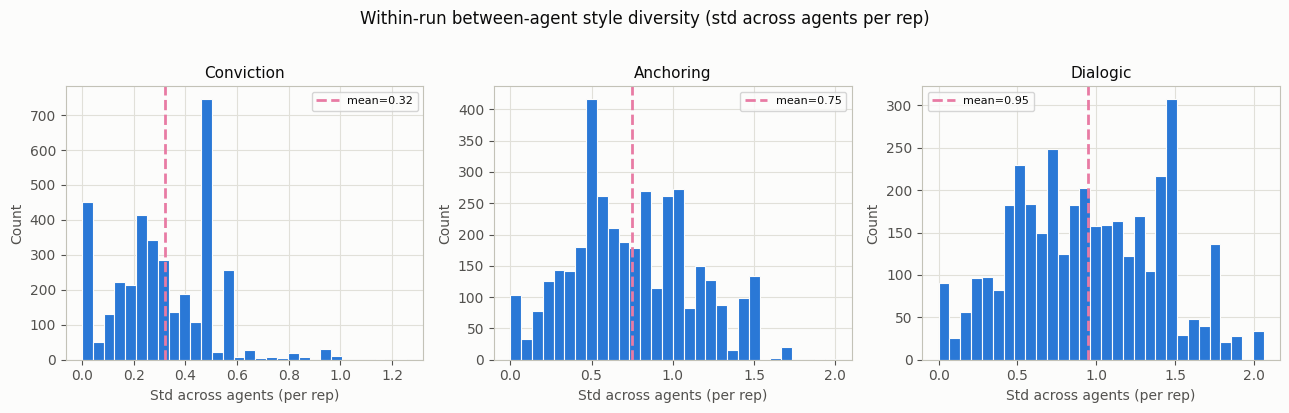

In [23]:
# within-run std across agents -> cell-level mean std (averaged over reps)
within_run_std = (
    agent_df.groupby(['dataset', 'topology', 'W', 'qid', 'rep_idx'])[DIMS]
    .std()
    .reset_index()
    .rename(columns={d: f'{d}_std' for d in DIMS})
)
within_cell_std = (
    within_run_std.groupby(['dataset', 'topology', 'W', 'qid'])[[f'{d}_std' for d in DIMS]]
    .mean()
    .reset_index()
)

# qid type alignment before merge
metrics_df_typed = metrics_df.copy()
metrics_df_typed['qid'] = metrics_df_typed['qid'].astype(str)
within_cell_std['qid'] = within_cell_std['qid'].astype(str)
std_merged = within_cell_std.merge(metrics_df_typed, on=['dataset', 'topology', 'W', 'qid'])

print("=== Overall within-run between-agent std ===")
for d in DIMS:
    v = within_run_std[f'{d}_std'].dropna()
    print(f"  {d}: mean={v.mean():.3f}  median={v.median():.3f}  >0.5: {(v > 0.5).mean():.1%}")

print("\n=== Spearman: within-run agent diversity vs outcomes ===")
for d in DIMS:
    for col, label in [('accuracy', 'Accuracy'), ('mean_rounds', 'Rounds'), ('p_sr', 'p_sr'), ('D_mean', 'Dominance'), ('n_eff', 'n_eff')]:
        sub = std_merged[[f'{d}_std', col]].dropna()
        r, p = stats.spearmanr(sub[f'{d}_std'], sub[col])
        sig = '**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.')
        print(f"  {d}_std / {label:12s}  rho={r:+.3f}  p={p:.4f}  {sig}")

# Visualise: distribution of within-run std per dimension
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Within-run between-agent style diversity (std across agents per rep)', fontsize=12, y=1.02, color=TEXT_PRI)

for ax, dim in zip(axes, DIMS):
    vals = within_run_std[f'{dim}_std'].dropna()
    ax.hist(vals, bins=30, color=CAT[0], edgecolor=SURFACE, linewidth=0.8)
    ax.axvline(vals.mean(), color=CAT[2], linewidth=2, linestyle='--', label=f'mean={vals.mean():.2f}')
    ax.set_title(dim.capitalize(), fontsize=11, color=TEXT_PRI)
    ax.set_xlabel('Std across agents (per rep)', color=TEXT_SEC)
    ax.set_ylabel('Count', color=TEXT_SEC)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Three-level overview: score → agent → system, split by dataset

**Score level** = every individual message. **Agent level** = each agent's mean (± std) over their rounds in a run. **System level** = mean over all 4 agents in a run.

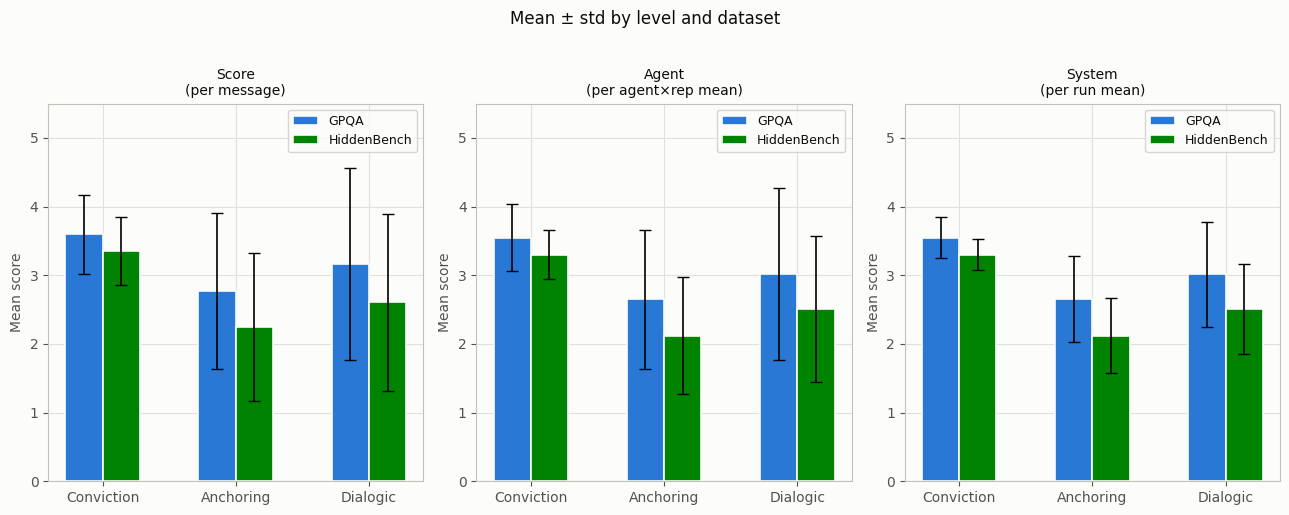

=== Score level ===
  gpqa: conviction=3.596±0.573  anchoring=2.768±1.134  dialogic=3.159±1.396
  hiddenbench: conviction=3.355±0.493  anchoring=2.241±1.077  dialogic=2.605±1.284

=== Agent level ===
  gpqa: conviction=3.548±0.484  anchoring=2.649±1.012  dialogic=3.014±1.254
  hiddenbench: conviction=3.300±0.355  anchoring=2.122±0.851  dialogic=2.509±1.065

=== System level ===
  gpqa: conviction=3.548±0.302  anchoring=2.649±0.624  dialogic=3.014±0.767
  hiddenbench: conviction=3.300±0.227  anchoring=2.122±0.540  dialogic=2.509±0.655


In [24]:
datasets = ['gpqa', 'hiddenbench']
ds_colors = {'gpqa': CAT[0], 'hiddenbench': CAT[1]}
ds_labels = {'gpqa': 'GPQA', 'hiddenbench': 'HiddenBench'}

# --- score level ---
score_stats = ling_df.groupby('dataset')[DIMS].agg(['mean', 'std'])

# --- agent level: per (rep, agent) mean across rounds ---
agent_df_all = (
    ling_df.groupby(['dataset', 'topology', 'W', 'qid', 'rep_idx', 'agent_idx'])[DIMS]
    .mean().reset_index()
)
agent_stats = agent_df_all.groupby('dataset')[DIMS].agg(['mean', 'std'])

# --- system level: per (rep) mean across all agents ---
system_df = (
    ling_df.groupby(['dataset', 'topology', 'W', 'qid', 'rep_idx'])[DIMS]
    .mean().reset_index()
)
system_stats = system_df.groupby('dataset')[DIMS].agg(['mean', 'std'])

levels = [
    ('Score\n(per message)', score_stats),
    ('Agent\n(per agent×rep mean)', agent_stats),
    ('System\n(per run mean)', system_stats),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.suptitle('Mean ± std by level and dataset', fontsize=12, y=1.02, color=TEXT_PRI)

x = np.arange(len(DIMS))
width = 0.28

for ax, (level_name, stats_df) in zip(axes, levels):
    for i, ds in enumerate(datasets):
        means = [stats_df.loc[ds, (d, 'mean')] for d in DIMS]
        stds  = [stats_df.loc[ds, (d, 'std')]  for d in DIMS]
        offset = (i - 0.5) * width
        bars = ax.bar(x + offset, means, width, yerr=stds, label=ds_labels[ds],
                      color=ds_colors[ds], edgecolor=SURFACE, linewidth=1.2,
                      capsize=4, error_kw={'linewidth': 1.2, 'color': TEXT_SEC})

    ax.set_title(level_name, fontsize=10, color=TEXT_PRI)
    ax.set_xticks(x)
    ax.set_xticklabels([d.capitalize() for d in DIMS])
    ax.set_ylabel('Mean score', color=TEXT_SEC)
    ax.set_ylim(0, 5.5)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print("=== Score level ===")
for ds in datasets:
    print(f"  {ds}: " + "  ".join(f"{d}={score_stats.loc[ds,(d,'mean')]:.3f}±{score_stats.loc[ds,(d,'std')]:.3f}" for d in DIMS))
print("\n=== Agent level ===")
for ds in datasets:
    print(f"  {ds}: " + "  ".join(f"{d}={agent_stats.loc[ds,(d,'mean')]:.3f}±{agent_stats.loc[ds,(d,'std')]:.3f}" for d in DIMS))
print("\n=== System level ===")
for ds in datasets:
    print(f"  {ds}: " + "  ".join(f"{d}={system_stats.loc[ds,(d,'mean')]:.3f}±{system_stats.loc[ds,(d,'std')]:.3f}" for d in DIMS))

## Agent diversity → outcomes, split by dataset

Key question: does the diversity→faster convergence and diversity→accuracy relationship hold in both datasets, or is it dataset-specific?

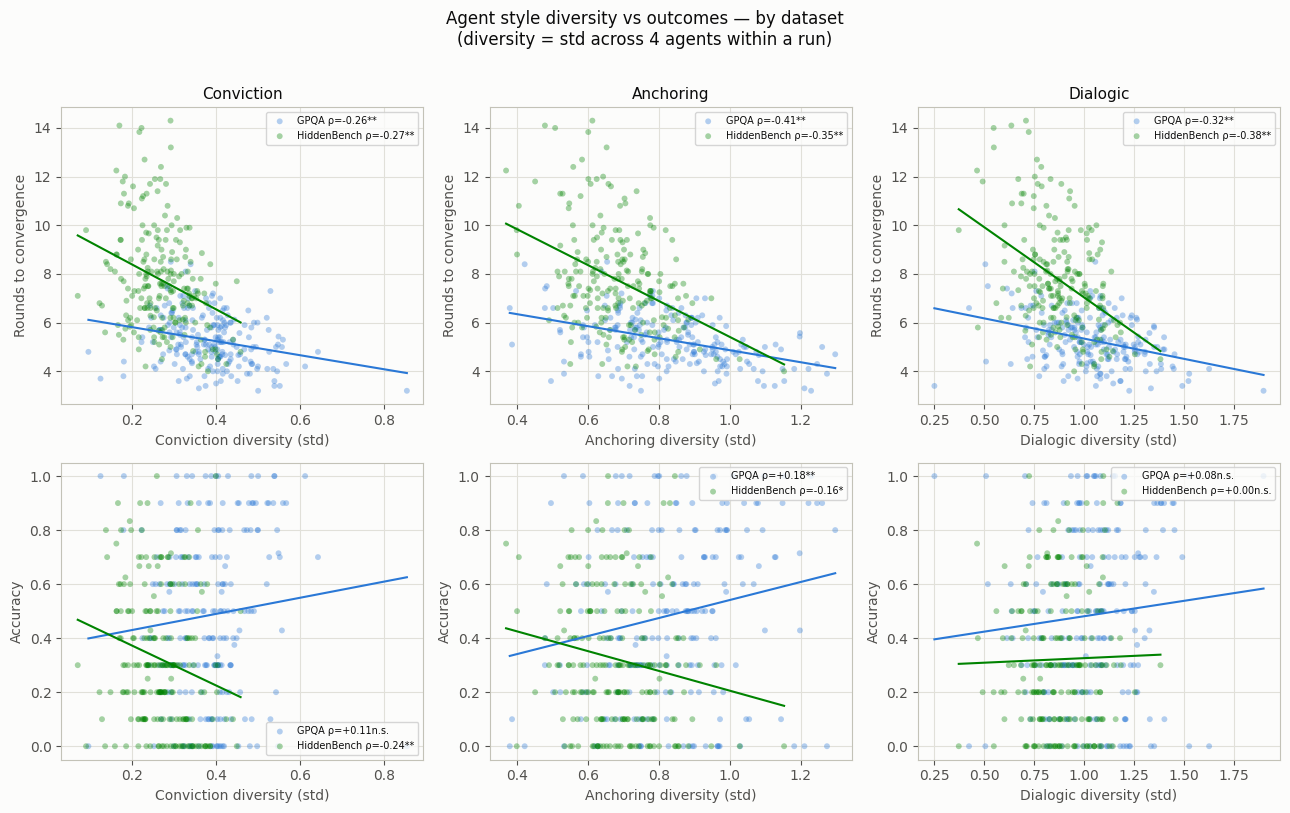

=== Spearman by dataset ===

GPQA:
  conviction_std / Rounds      rho=-0.259  p=0.0001  **
  conviction_std / Accuracy    rho=+0.109  p=0.1151  n.s.
  anchoring_std / Rounds      rho=-0.406  p=0.0000  **
  anchoring_std / Accuracy    rho=+0.184  p=0.0074  **
  dialogic_std / Rounds      rho=-0.323  p=0.0000  **
  dialogic_std / Accuracy    rho=+0.083  p=0.2311  n.s.

HiddenBench:
  conviction_std / Rounds      rho=-0.268  p=0.0001  **
  conviction_std / Accuracy    rho=-0.240  p=0.0005  **
  anchoring_std / Rounds      rho=-0.346  p=0.0000  **
  anchoring_std / Accuracy    rho=-0.164  p=0.0172  *
  dialogic_std / Rounds      rho=-0.381  p=0.0000  **
  dialogic_std / Accuracy    rho=+0.001  p=0.9846  n.s.


In [25]:
# within-run agent diversity per rep
within_rep = (
    agent_df_all.groupby(['dataset', 'topology', 'W', 'qid', 'rep_idx'])[DIMS]
    .std().reset_index()
    .rename(columns={d: f'{d}_std' for d in DIMS})
)
within_cell = (
    within_rep.groupby(['dataset', 'topology', 'W', 'qid'])[[f'{d}_std' for d in DIMS]]
    .mean().reset_index()
)
within_cell['qid'] = within_cell['qid'].astype(str)
metrics_typed = metrics_df.copy()
metrics_typed['qid'] = metrics_typed['qid'].astype(str)
std_merged = within_cell.merge(metrics_typed, on=['dataset', 'topology', 'W', 'qid'])

# Scatter: anchoring_std vs rounds, coloured by dataset (anchoring has clearest signal)
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
fig.suptitle('Agent style diversity vs outcomes — by dataset\n(diversity = std across 4 agents within a run)', fontsize=12, y=1.01, color=TEXT_PRI)

outcomes = [('mean_rounds', 'Rounds to convergence'), ('accuracy', 'Accuracy')]

for row_i, (outcome_col, outcome_label) in enumerate(outcomes):
    for col_i, dim in enumerate(DIMS):
        ax = axes[row_i, col_i]
        for ds in datasets:
            sub = std_merged[std_merged['dataset'] == ds][[f'{dim}_std', outcome_col]].dropna()
            r, p = stats.spearmanr(sub[f'{dim}_std'], sub[outcome_col])
            sig = '**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.')
            ax.scatter(sub[f'{dim}_std'], sub[outcome_col], alpha=0.35, s=18,
                       color=ds_colors[ds], edgecolors='none', label=f'{ds_labels[ds]} ρ={r:+.2f}{sig}')
            m, b = np.polyfit(sub[f'{dim}_std'], sub[outcome_col], 1)
            xs = np.linspace(sub[f'{dim}_std'].min(), sub[f'{dim}_std'].max(), 100)
            ax.plot(xs, m * xs + b, color=ds_colors[ds], linewidth=1.5)

        ax.set_xlabel(f'{dim.capitalize()} diversity (std)', color=TEXT_SEC)
        ax.set_ylabel(outcome_label, color=TEXT_SEC)
        if row_i == 0:
            ax.set_title(dim.capitalize(), fontsize=11, color=TEXT_PRI)
        ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

print("=== Spearman by dataset ===")
for ds in datasets:
    print(f"\n{ds_labels[ds]}:")
    sub_ds = std_merged[std_merged['dataset'] == ds]
    for d in DIMS:
        for col, label in [('mean_rounds', 'Rounds'), ('accuracy', 'Accuracy')]:
            sub = sub_ds[[f'{d}_std', col]].dropna()
            r, p = stats.spearmanr(sub[f'{d}_std'], sub[col])
            sig = '**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.')
            print(f"  {d}_std / {label:10s}  rho={r:+.3f}  p={p:.4f}  {sig}")

---
## Key findings — presentation summary

### Finding 1 · Stylistic diversity between agents predicts self-organisational dynamics (strongest result)

When agents within the same run differ in how they communicate — especially in **anchoring** (how much they reference prior arguments) and **dialogic** engagement — the system converges in significantly **fewer rounds** (Spearman ρ ≈ −0.51 to −0.54, p < 0.001, consistent across both datasets and both topologies).

Crucially, this is a **predictor**, not just a description: linguistic diversity is measured from the messages themselves, and it predicts the dynamical outcome (rounds to convergence) independently. The mechanism connects directly to **self-reinforcement**: agents who are stylistically similar tend to repeat their own position unchanged (high p_sr), while a heterogeneous group creates genuine back-and-forth that resolves faster. Linguistic style is not just a surface readout of the dynamics — it appears causally upstream of how quickly the system self-organises.

### Finding 2 · The accuracy effect of diversity flips by dataset difficulty

The faster convergence is universal, but whether diversity helps or hurts accuracy depends on task difficulty:
- **GPQA** (hard, expert-level): more diversity → slightly *higher* accuracy (anchoring_std ρ = +0.18**)
- **HiddenBench** (easier): more diversity → slightly *lower* accuracy (conviction_std ρ = −0.24**)

On hard tasks, stylistic heterogeneity pushes agents to genuinely reconsider — diversity is productive. On easier tasks, a group that communicates similarly is already efficient and diversity introduces noise.

### Finding 3 · Linguistic style is orthogonal to the structural self-organisation motifs (useful null)

Bistability, limit cycles, and dominance show essentially no correlation with mean linguistic scores. The linguistic dimensions capture something *different* from the structural motifs — an orthogonal signal, not a restatement of what is already measured. The one exception: high **dialogic** diversity weakly tracks higher dominance (ρ = +0.16**), consistent with a dominant hub being the most conversational agent.

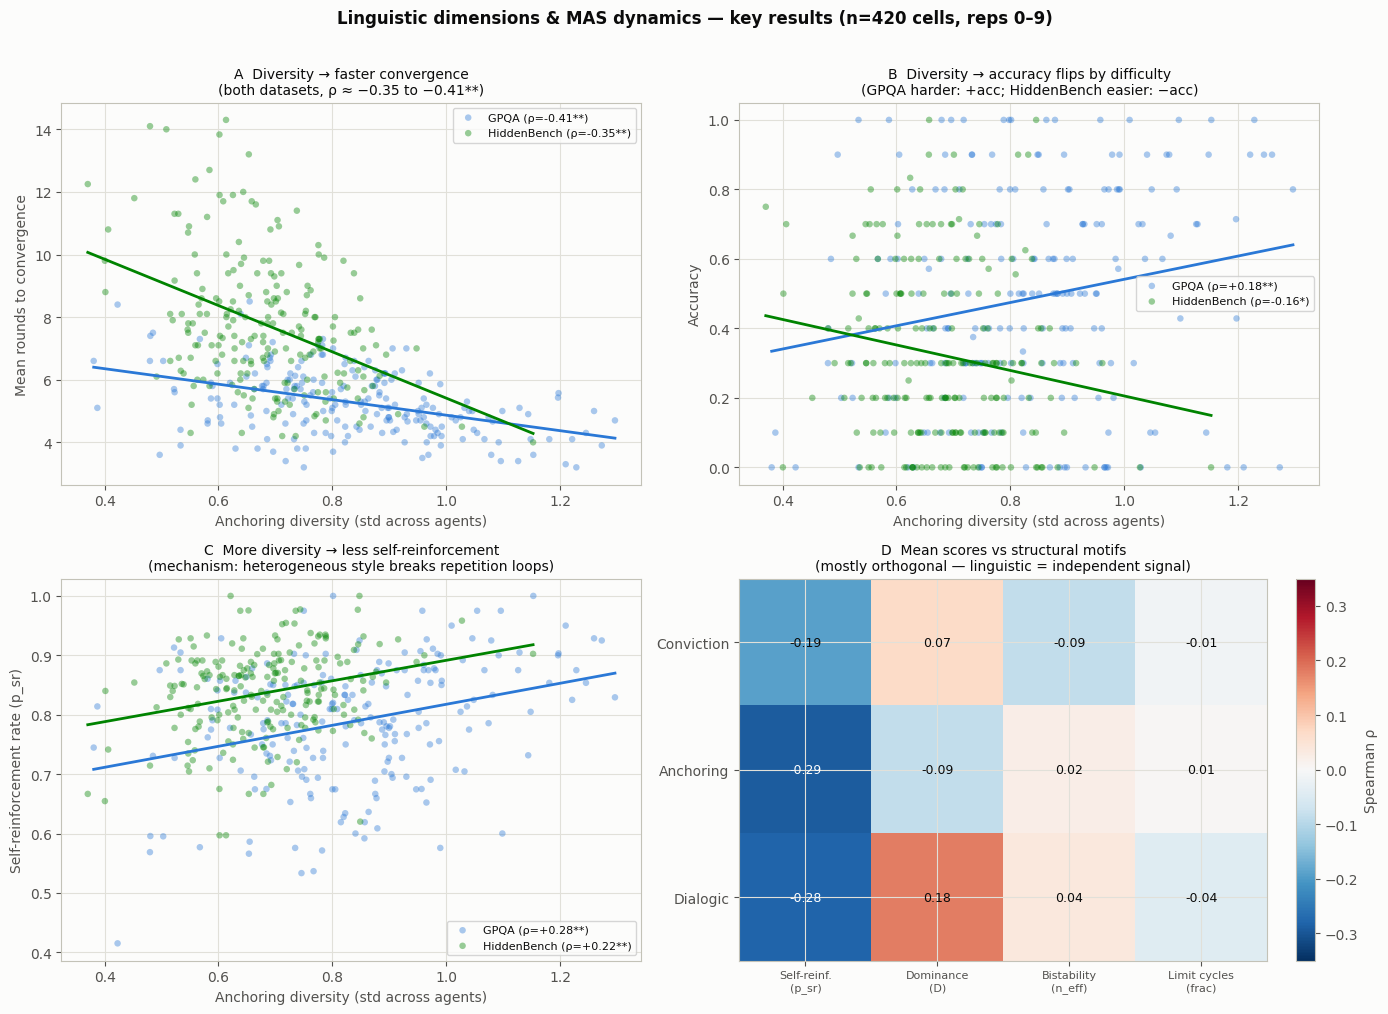

In [27]:
# ── Summary visualisation: two panels for presentation ──────────────────────

fig = plt.figure(figsize=(14, 10))
fig.patch.set_facecolor(SURFACE)

# ── Panel A: diversity vs rounds, both datasets, anchoring (clearest signal) ─
ax1 = fig.add_subplot(2, 2, 1)
within_rep_viz = (
    agent_df_all.groupby(['dataset', 'topology', 'W', 'qid', 'rep_idx'])[DIMS]
    .std().reset_index()
    .rename(columns={d: f'{d}_std' for d in DIMS})
)
within_cell_viz = (
    within_rep_viz.groupby(['dataset', 'topology', 'W', 'qid'])[[f'{d}_std' for d in DIMS]]
    .mean().reset_index()
)
within_cell_viz['qid'] = within_cell_viz['qid'].astype(str)
sm_viz = within_cell_viz.merge(metrics_df_typed, on=['dataset', 'topology', 'W', 'qid'])

for ds in datasets:
    sub = sm_viz[sm_viz['dataset'] == ds][['anchoring_std', 'mean_rounds']].dropna()
    r, p = stats.spearmanr(sub['anchoring_std'], sub['mean_rounds'])
    ax1.scatter(sub['anchoring_std'], sub['mean_rounds'], alpha=0.4, s=22,
                color=ds_colors[ds], edgecolors='none', label=f'{ds_labels[ds]} (ρ={r:+.2f}**)')
    m, b = np.polyfit(sub['anchoring_std'], sub['mean_rounds'], 1)
    xs = np.linspace(sub['anchoring_std'].min(), sub['anchoring_std'].max(), 100)
    ax1.plot(xs, m*xs+b, color=ds_colors[ds], linewidth=2)

ax1.set_xlabel('Anchoring diversity (std across agents)', color=TEXT_SEC)
ax1.set_ylabel('Mean rounds to convergence', color=TEXT_SEC)
ax1.set_title('A  Diversity → faster convergence\n(both datasets, ρ ≈ −0.35 to −0.41**)', fontsize=10, color=TEXT_PRI)
ax1.legend(fontsize=8)

# ── Panel B: diversity vs accuracy, dataset comparison ───────────────────────
ax2 = fig.add_subplot(2, 2, 2)
for ds in datasets:
    sub = sm_viz[sm_viz['dataset'] == ds][['anchoring_std', 'accuracy']].dropna()
    r, p = stats.spearmanr(sub['anchoring_std'], sub['accuracy'])
    sig = '**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.')
    ax2.scatter(sub['anchoring_std'], sub['accuracy'], alpha=0.4, s=22,
                color=ds_colors[ds], edgecolors='none', label=f'{ds_labels[ds]} (ρ={r:+.2f}{sig})')
    m, b = np.polyfit(sub['anchoring_std'], sub['accuracy'], 1)
    xs = np.linspace(sub['anchoring_std'].min(), sub['anchoring_std'].max(), 100)
    ax2.plot(xs, m*xs+b, color=ds_colors[ds], linewidth=2)

ax2.set_xlabel('Anchoring diversity (std across agents)', color=TEXT_SEC)
ax2.set_ylabel('Accuracy', color=TEXT_SEC)
ax2.set_title('B  Diversity → accuracy flips by difficulty\n(GPQA harder: +acc; HiddenBench easier: −acc)', fontsize=10, color=TEXT_PRI)
ax2.legend(fontsize=8)

# ── Panel C: diversity vs p_sr (self-reinforcement link) ─────────────────────
ax3 = fig.add_subplot(2, 2, 3)
for ds in datasets:
    sub = sm_viz[sm_viz['dataset'] == ds][['anchoring_std', 'p_sr']].dropna()
    r, p = stats.spearmanr(sub['anchoring_std'], sub['p_sr'])
    sig = '**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.')
    ax3.scatter(sub['anchoring_std'], sub['p_sr'], alpha=0.4, s=22,
                color=ds_colors[ds], edgecolors='none', label=f'{ds_labels[ds]} (ρ={r:+.2f}{sig})')
    m, b = np.polyfit(sub['anchoring_std'], sub['p_sr'], 1)
    xs = np.linspace(sub['anchoring_std'].min(), sub['anchoring_std'].max(), 100)
    ax3.plot(xs, m*xs+b, color=ds_colors[ds], linewidth=2)

ax3.set_xlabel('Anchoring diversity (std across agents)', color=TEXT_SEC)
ax3.set_ylabel('Self-reinforcement rate (p_sr)', color=TEXT_SEC)
ax3.set_title('C  More diversity → less self-reinforcement\n(mechanism: heterogeneous style breaks repetition loops)', fontsize=10, color=TEXT_PRI)
ax3.legend(fontsize=8)

# ── Panel D: null result heatmap — linguistic means vs structural motifs ──────
ax4 = fig.add_subplot(2, 2, 4)
null_metrics = ['p_sr', 'D_mean', 'n_eff', 'lc_frac']
null_labels  = ['Self-reinf.\n(p_sr)', 'Dominance\n(D)', 'Bistability\n(n_eff)', 'Limit cycles\n(frac)']
null_corr = np.zeros((3, 4))
for i, dim in enumerate(DIMS):
    for j, col in enumerate(null_metrics):
        sub = merged[[dim, col]].dropna()
        r, _ = stats.spearmanr(sub[dim], sub[col])
        null_corr[i, j] = r

im = ax4.imshow(null_corr, cmap='RdBu_r', vmin=-0.35, vmax=0.35, aspect='auto')
ax4.set_xticks(range(4))
ax4.set_xticklabels(null_labels, fontsize=8)
ax4.set_yticks(range(3))
ax4.set_yticklabels([d.capitalize() for d in DIMS])
ax4.set_title('D  Mean scores vs structural motifs\n(mostly orthogonal — linguistic = independent signal)', fontsize=10, color=TEXT_PRI)
for i in range(3):
    for j in range(4):
        ax4.text(j, i, f'{null_corr[i,j]:.2f}', ha='center', va='center',
                 fontsize=9, color='white' if abs(null_corr[i,j]) > 0.2 else TEXT_PRI)
plt.colorbar(im, ax=ax4, label='Spearman ρ', fraction=0.04)

plt.suptitle('Linguistic dimensions & MAS dynamics — key results (n=420 cells, reps 0–9)',
             fontsize=12, y=1.01, color=TEXT_PRI, fontweight='bold')
plt.tight_layout()
plt.show()